# Eğitilmiş NARX Transformer Model Katmanlarının Görselleştirilmesi
Bu notebook, **epoch_model_763.py**'nin Jupyter Notebook uyarlamasıdır.
Eğitilmiş modelin **Backbone (Evrişim)**, **Neck (Transformer)** ve **Head (Doğrusal)** katmanlarına ait ağırlıkları (parametreleri), filtreleri (kernel) ve öznitelik algılayıcılarını (feature maps/attention projeksiyonları) görselleştirir.

In [1]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Uyarıları Gizle (Görsel Temizlik İçin)
import warnings
warnings.filterwarnings('ignore')

# Modeli Yükle
model_yolu = r'C:\Users\TR\Desktop\myz dönem projesi\NARX-Transformer-SoH-main\models\trained_model_0.017068_763.pt'
model = torch.load(model_yolu, map_location='cpu', weights_only=False)
model.eval()
print('Model başarıyla yüklendi!')

Model başarıyla yüklendi!
Model mimarisi 'egitilmis_mimari_ozeti.txt' dosyasına kaydedildi.
Eğitilmiş modelin ağırlık detayları 'egitilmis_model_ozeti.txt' dosyasına kaydedildi.
Model başarıyla yüklendi!


## 1. BACKBONE (Özellik Çıkarımı: Evrişim Filtreleri)
Modelin en başındaki Evrişim (`Conv2d`) katmanlarının sahip olduğu çekirdek (kernel/filtre) ağırlıklarını görselleştiriyoruz.
İlk birkaç filtreyi hem ısı haritası hem de sayısal 5'er/9'ar değerleriyle, filtre içerisine yazılmış olarak görüntülüyoruz.

Conv_layer Ağırlık Boyutu: (16, 7, 3, 3)


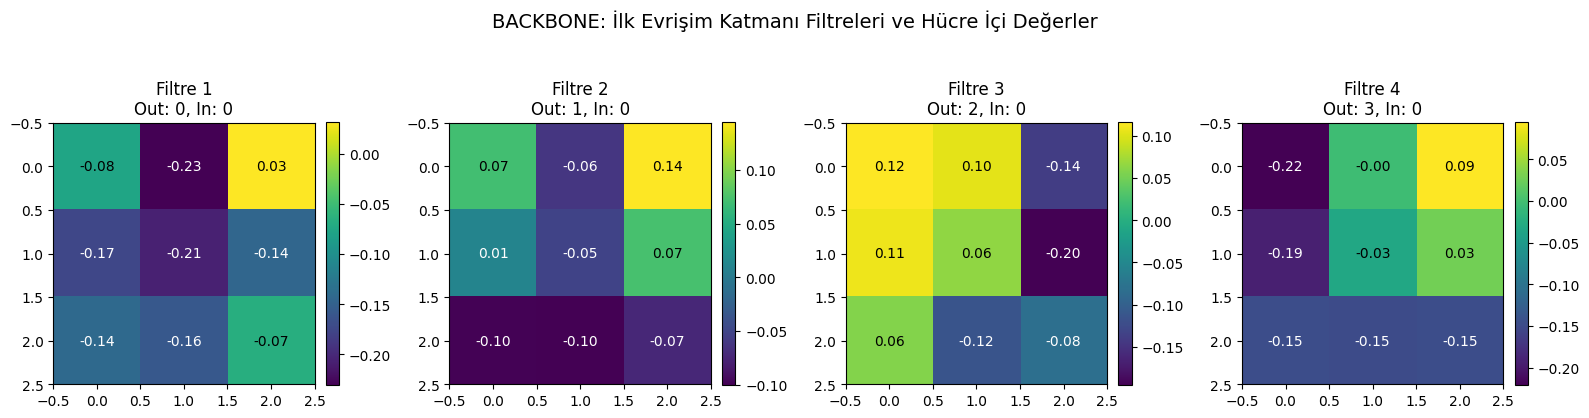

In [2]:
conv_layer = model.conv_layer
weights = conv_layer.weight.detach().cpu().numpy()

print(f'Conv_layer Ağırlık Boyutu: {weights.shape}')
# weights -> (out_channels, in_channels, kH, kW)
# İlk 4 filtreyi görelim (sadece 1. giriş kanalına [0] karşılık gelenler)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i in range(4):
    if i < weights.shape[0]:
        # 2 Boyutlu matris (örneğin 3x3)
        filter_2d = weights[i, 0, :, :]
        
        ax = axes[i]
        im = ax.imshow(filter_2d, cmap='viridis')
        ax.set_title(f'Filtre {i+1}\nOut: {i}, In: 0')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        
        # Hücrelerin içerisine sayısal değerleri yazdıralım
        for y in range(filter_2d.shape[0]):
            for x in range(filter_2d.shape[1]):
                val = filter_2d[y, x]
                color = 'white' if val < (filter_2d.max() + filter_2d.min()) / 2 else 'black'
                ax.text(x, y, f'{val:.2f}', ha='center', va='center', color=color, fontsize=10)

plt.suptitle('BACKBONE: İlk Evrişim Katmanı Filtreleri ve Hücre İçi Değerler', fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

## 2. NECK (Zaman/Ek Özellik İlişkilendirmesi: Transformer Katmanları)
Transformer bloklarındaki Attention (Dikkat) mekanizmasının projeksiyon matrislerini ısı haritası (heatmap) olarak inceliyoruz.
Matris çok büyükse, sadece ilk 16x16'lık (veya tüm) kısmını, ağırlık şiddeti renkleriyle birlikte görüntülüyoruz.

Neck (Transformer out_proj) Ağırlık Boyutu: (16, 16)


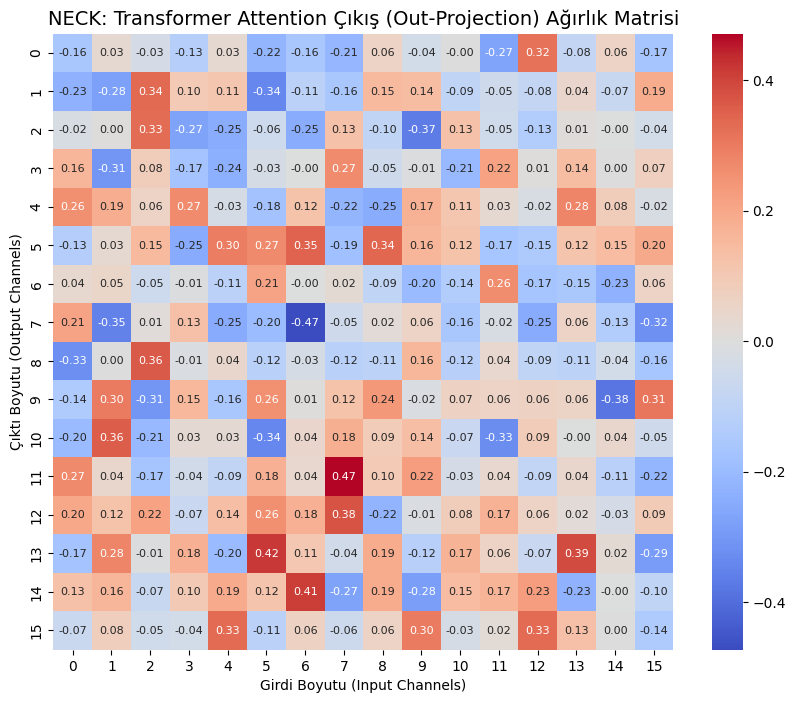

In [3]:
# Transformer Encoder Çıkış Projeksiyon Ağırlıkları (Attention Head Çıktısını Birleştiren Matris)
neck_weight = model.encoder_layer.self_attn.out_proj.weight.detach().cpu().numpy()

print(f'Neck (Transformer out_proj) Ağırlık Boyutu: {neck_weight.shape}')

# Eğer çok büyükse (örn. 512x512) tamamını tek tek sayılarla çizdirmek okunmaz olur,
# ancak bizim matrisimiz ~16x16 olduğu için tamamını içine değer yazdırarak çizebiliriz.
plt.figure(figsize=(10, 8))
sns.heatmap(neck_weight, annot=True, fmt='.2f', cmap='coolwarm', cbar=True, annot_kws={'size': 8})
plt.title('NECK: Transformer Attention Çıkış (Out-Projection) Ağırlık Matrisi', fontsize=14)
plt.xlabel('Girdi Boyutu (Input Channels)')
plt.ylabel('Çıktı Boyutu (Output Channels)')
plt.show()

## 3. HEAD (Son Karar / Tahmin Katmanı)
Transformer'dan gelen soyut özelliklerin, nihai model tahminine (SoH vs.) çevrildiği doğrusal (Linear) katman ağırlıkları.

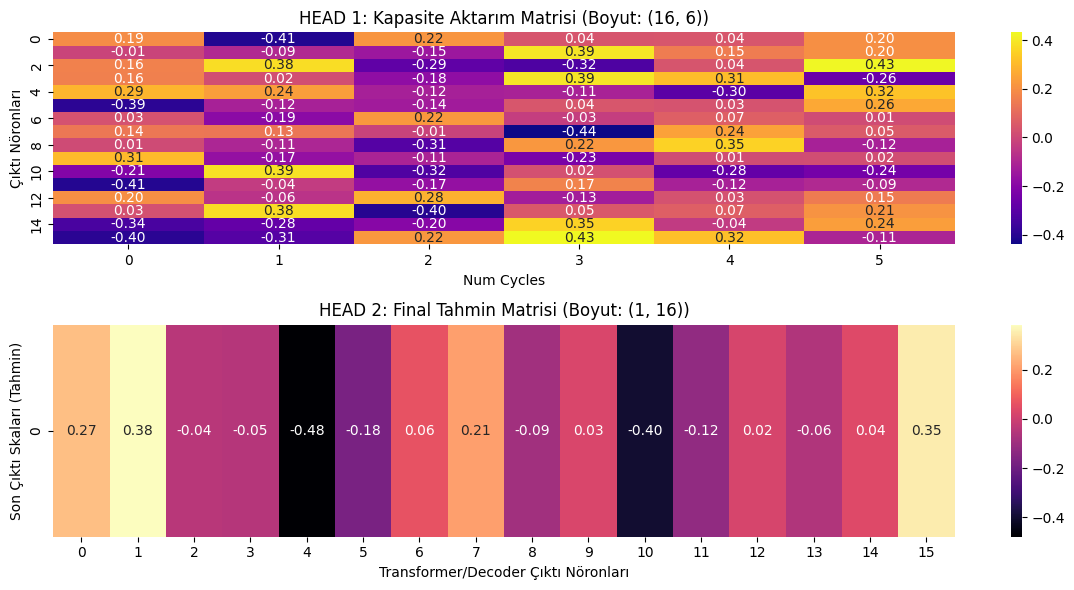

In [4]:
# Head'deki doğrusal katmanlar
head_weight_cap = model.cap_linear_layer.weight.detach().cpu().numpy()
head_weight_final = model.final_linear_layer.weight.detach().cpu().numpy()

fig, axes = plt.subplots(2, 1, figsize=(12, 6))

# 1. Head Linear Layer
sns.heatmap(head_weight_cap, annot=True, fmt='.2f', cmap='plasma', ax=axes[0], cbar=True)
axes[0].set_title(f'HEAD 1: Kapasite Aktarım Matrisi (Boyut: {head_weight_cap.shape})')
axes[0].set_xlabel('Num Cycles')
axes[0].set_ylabel('Çıktı Nöronları')

# 2. Head Final Linear Layer
sns.heatmap(head_weight_final, annot=True, fmt='.2f', cmap='magma', ax=axes[1], cbar=True)
axes[1].set_title(f'HEAD 2: Final Tahmin Matrisi (Boyut: {head_weight_final.shape})')
axes[1].set_xlabel('Transformer/Decoder Çıktı Nöronları')
axes[1].set_ylabel('Son Çıktı Skaları (Tahmin)')

plt.tight_layout()
plt.show()